# Notebook 20 — Final Comparison: Beyond F1

**Closing chapter of the thesis.** Ranking models by a single point estimate of F1 is not enough: a system intended for deployment on critical infrastructure (smart-grid AMI) must be judged along **six axes**: detection, **uncertainty** (NB15), **privacy** (NB17), **adversarial robustness** (NB18), **edge efficiency** (NB19) and **generalization** (NB13/NB16). This notebook:

1. Consolidates **every** metric into a single master comparison table.
2. Adds genuine **statistical rigor** (per-sample predictions are available): **bootstrap confidence intervals** on F1 and a **paired McNemar test** between the leading models, to establish whether the observed differences are significant or merely sampling noise.
3. Builds the **Pareto frontier** of detection vs. edge cost (model size, latency).
4. Examines **recall by attack type** (a model x attack heatmap) to expose complementarity.
5. Integrates the **six axes** into a multidimensional radar chart.
6. Issues **per-scenario deployment recommendations** and discusses the **limitations** of the work.

> Evaluation protocol: every detector is evaluated on the same `test_with_attacks` set (604,999 minutes, 7 FDI attack types). LightGBM is supervised (a reference ceiling that requires labels); all other models are unsupervised.

## 0. Setup and metric loading

In [1]:
import os, json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (f1_score, fbeta_score, precision_score, recall_score,
                             average_precision_score, roc_auc_score,
                             precision_recall_curve, confusion_matrix)
warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid'); plt.rcParams['font.size'] = 11

BASE = '/Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/'
DATA = os.path.join(BASE, 'data'); FIG = os.path.join(BASE, 'figures')

# Map each model -> (metrics json, predictions csv, score column, binary-prediction column)
MODELS = {
    'LightGBM':       ('metrics_lightgbm.json',                'predictions_lightgbm.csv',                'score',     'pred'),
    'Dense-AE':       ('metrics_dense_autoencoder.json',       'predictions_dense_autoencoder.csv',       'dae_score', 'dae_pred_smooth'),
    'Stacking':       ('metrics_stacking.json',                'predictions_stacking.csv',                'score',     'pred_sm'),
    'KMeans+IF':      ('metrics_kmeans_if.json',               'predictions_kmeans_if.csv',               'kmif_score','kmif_pred_smooth'),
    'Isolation Forest':('metrics_isolation_forest.json',       'predictions_isolation_forest.csv',        'if_score',  'if_pred_smooth'),
    'LSTM-AE':        ('metrics_lstm_autoencoder.json',        'predictions_lstm_autoencoder.csv',        'lstm_score','lstm_pred_smooth'),
    'VAE':            ('metrics_vae.json',                     'predictions_vae.csv',                     'vae_score', None),
    'Transformer-AE': ('metrics_transformer_autoencoder.json', 'predictions_transformer_autoencoder.csv', 'score',     'pred'),
    'CNN-AE':         ('metrics_cnn_autoencoder.json',         'predictions_cnn_autoencoder.csv',         'score',     'pred'),
}
META = {}
for name,(jf,_,_,_) in MODELS.items():
    p = os.path.join(DATA, jf)
    META[name] = json.load(open(p)) if os.path.exists(p) else {}
print(f'Metrics loaded for {len(META)} models')

Metrics loaded for 9 models


## 1. Master detection table

Consolidates F1/F2/AUC-PR/AUC-ROC together with the edge footprint (model size, latency). Any metric missing from a JSON file is left as `NaN` and recomputed from the predictions below.

In [2]:
def g(d, *keys, default=np.nan):
    # Return the first key present (and non-None); tolerates the differing key
    # names used across the per-model JSON files.
    for k in keys:
        if k in d and d[k] is not None: return d[k]
    return default

rows = []
for name, m in META.items():
    rows.append({
        'model': name,
        'type': 'supervised' if name=='LightGBM' else 'unsupervised',
        'F1':       g(m,'f1','F1'),
        'F2':       g(m,'f2','F2'),
        'precision':g(m,'precision','P'),
        'recall':   g(m,'recall','R'),
        'AUC_PR':   g(m,'auc_pr','AUC_PR','aucpr'),
        'AUC_ROC':  g(m,'auc_roc','AUC_ROC'),
        'size_KB':  g(m,'model_size_kb','size_kb','model_kb'),
        'ms_sample':g(m,'ms_per_sample','ms_sample'),
    })
master = pd.DataFrame(rows).sort_values('F1', ascending=False).reset_index(drop=True)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
print('MASTER DETECTION TABLE (sorted by F1)')
print('='*100)
print(master.to_string(index=False))

MASTER DETECTION TABLE (sorted by F1)
           model         type     F1     F2  precision  recall  AUC_PR  AUC_ROC    size_KB  ms_sample
        LightGBM   supervised 0.9104 0.8861     0.9540  0.8706  0.9408   0.9627  3110.9000     0.0025
        Stacking unsupervised 0.8277 0.7711     0.9433  0.7374  0.9101   0.9630        NaN        NaN
        Dense-AE unsupervised 0.8083 0.8073     0.8099  0.8067  0.8176   0.9304   134.0000     0.0004
       KMeans+IF unsupervised 0.7895 0.7651     0.8337  0.7497  0.7644   0.9270 17425.4000     0.0114
Isolation Forest unsupervised 0.7544 0.7499     0.7621  0.7469  0.7824   0.9266  6910.8000     0.0095
         LSTM-AE unsupervised 0.7306 0.7931     0.6457  0.8411  0.8853   0.9429  3178.6000     0.0038
             VAE unsupervised 0.7152 0.7288     0.6938  0.7380  0.5453   0.8908    27.5000     0.0003
  Transformer-AE unsupervised 0.6138 0.6638     0.5453  0.7020  0.5870   0.8840  1102.8000     0.0010
          CNN-AE unsupervised 0.4333 0.4879 

## 2. Statistical rigor: are the differences significant?

A ranking based on point F1 alone cannot tell us whether the gap between two models is real or an artifact of sampling. Because we **do hold the per-sample prediction** of each detector across the 604,999 test rows, we compute:

- A **bootstrap confidence interval** on F1 (resampling with replacement; 2.5th-97.5th percentile).
- A **paired McNemar test** between the leading models, which compares their discordant errors (the cases where one model is right and the other wrong).

In [3]:
# Load per-sample predictions (only the columns we actually need)
def load_preds(name):
    _, csv, sc, pc = MODELS[name]
    p = os.path.join(DATA, csv)
    cols = ['label', sc, 'attack_type', 'severity'] + ([pc] if pc else [])
    df = pd.read_csv(p, usecols=lambda c: c in cols)
    y = df['label'].astype(int).values
    score = df[sc].values
    if pc:
        yp = df[pc].astype(int).values
    else:  # VAE has no stored binary column: threshold the score at the saved cutoff
        thr = g(META[name], 'threshold', default=np.nanmedian(score))
        yp = (score > thr).astype(int)
    return y, score, yp, df['attack_type'].values, df['severity'].values

PRED = {}
for name in MODELS:
    try:
        PRED[name] = load_preds(name)
        print(f'  {name:18s} {len(PRED[name][0]):,} samples')
    except Exception as e:
        print(f'  {name:18s} ERROR {e}')

  LightGBM           604,999 samples
  Dense-AE           604,999 samples
  Stacking           604,999 samples
  KMeans+IF          604,999 samples
  Isolation Forest   604,999 samples
  LSTM-AE            604,999 samples
  VAE                604,999 samples
  Transformer-AE     604,999 samples
  CNN-AE             604,999 samples


In [4]:
def boot_f1_ci(y, yp, n_boot=300, seed=42):
    # 95% bootstrap CI for F1: resample sample indices with replacement and
    # take the 2.5th/97.5th percentiles of the resulting F1 distribution.
    rng = np.random.default_rng(seed)
    n = len(y); f1s = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.integers(0, n, n)
        f1s[b] = f1_score(y[idx], yp[idx], zero_division=0)
    return f1_score(y, yp, zero_division=0), np.percentile(f1s, 2.5), np.percentile(f1s, 97.5)

print('BOOTSTRAP CONFIDENCE INTERVAL OF F1 (95%, n_boot=300)')
print('='*64)
ci_rows = []
for name in PRED:
    y, _, yp, _, _ = PRED[name]
    f1, lo, hi = boot_f1_ci(y, yp)
    ci_rows.append({'model': name, 'F1': f1, 'CI_low': lo, 'CI_high': hi,
                    'CI_width': hi-lo})
    print(f'  {name:18s} F1={f1:.4f}  CI95=[{lo:.4f}, {hi:.4f}]')
ci_df = pd.DataFrame(ci_rows).sort_values('F1', ascending=False)

BOOTSTRAP CONFIDENCE INTERVAL OF F1 (95%, n_boot=300)
  LightGBM           F1=0.9104  CI95=[0.9090, 0.9115]
  Dense-AE           F1=0.8083  CI95=[0.8064, 0.8102]
  Stacking           F1=0.8277  CI95=[0.8256, 0.8296]
  KMeans+IF          F1=0.7895  CI95=[0.7870, 0.7916]
  Isolation Forest   F1=0.7544  CI95=[0.7525, 0.7564]
  LSTM-AE            F1=0.7306  CI95=[0.7285, 0.7326]
  VAE                F1=0.6763  CI95=[0.6739, 0.6785]
  Transformer-AE     F1=0.6138  CI95=[0.6113, 0.6164]
  CNN-AE             F1=0.4333  CI95=[0.4309, 0.4357]


In [5]:
from scipy.stats import chi2 as _chi2

def mcnemar_pair(n1, n2):
    # Paired McNemar test (chi2, df=1, with continuity correction), computed by
    # hand. Both models share the same labels, so we only contrast their
    # discordant cells: b = A right & B wrong, c = A wrong & B right.
    y1, _, p1, _, _ = PRED[n1]; y2, _, p2, _, _ = PRED[n2]
    n = min(len(y1), len(y2))
    yt = y1[:n]  # identical labels (same test set)
    c1 = (p1[:n] == yt); c2 = (p2[:n] == yt)
    b = int((c1 & ~c2).sum())   # only model A is right
    c = int((~c1 & c2).sum())   # only model B is right
    stat = (abs(b - c) - 1)**2 / (b + c) if (b + c) > 0 else 0.0
    pv = float(_chi2.sf(stat, df=1))
    return b, c, stat, pv

top = list(ci_df['model'].head(4))
print('PAIRED McNEMAR TEST among the 4 best (continuity correction)')
print('='*78)
print(f'  {"pair":34s} {"only A":>8s} {"only B":>8s} {"chi2":>10s} {"p-value":>12s}')
print('-'*78)
mcn_rows = []
for i in range(len(top)):
    for j in range(i+1, len(top)):
        b, c, chi2, pv = mcnemar_pair(top[i], top[j])
        sig = '***' if pv<0.001 else ('**' if pv<0.01 else ('*' if pv<0.05 else 'ns'))
        print(f'  {top[i]+" vs "+top[j]:34s} {b:>8,d} {c:>8,d} {chi2:>10.1f} {pv:>12.2e} {sig}')
        mcn_rows.append({'A':top[i],'B':top[j],'only_A':b,'only_B':c,'chi2':chi2,'p':pv})
mcn_df = pd.DataFrame(mcn_rows)
print('\n  *** p<0.001  ** p<0.01  * p<0.05  ns = not significant')
print('  At N=604,999 almost any difference reaches significance: what matters is the')
print('  EFFECT SIZE (only A vs only B), not the p-value on its own.')

PAIRED McNEMAR TEST among the 4 best (continuity correction)
  pair                                 only A   only B       chi2      p-value
------------------------------------------------------------------------------
  LightGBM vs Stacking                 15,889    2,770     9222.5     0.00e+00 ***
  LightGBM vs Dense-AE                 22,317    1,877    17266.8     0.00e+00 ***
  LightGBM vs KMeans+IF                24,110    2,010    18697.0     0.00e+00 ***
  Stacking vs Dense-AE                 16,410    9,089     2101.4     0.00e+00 ***
  Stacking vs KMeans+IF                18,796    9,815     2818.5     0.00e+00 ***
  Dense-AE vs KMeans+IF                15,756   14,096       92.2     7.84e-22 ***

  *** p<0.001  ** p<0.01  * p<0.05  ns = not significant
  At N=604,999 almost any difference reaches significance: what matters is the
  EFFECT SIZE (only A vs only B), not the p-value on its own.


## 3. Pareto frontier: detection vs. edge cost

A model is **Pareto-optimal** if no other model dominates it simultaneously in detection (F1) and cost (size, latency). This is the honest lens for deployment on a meter.

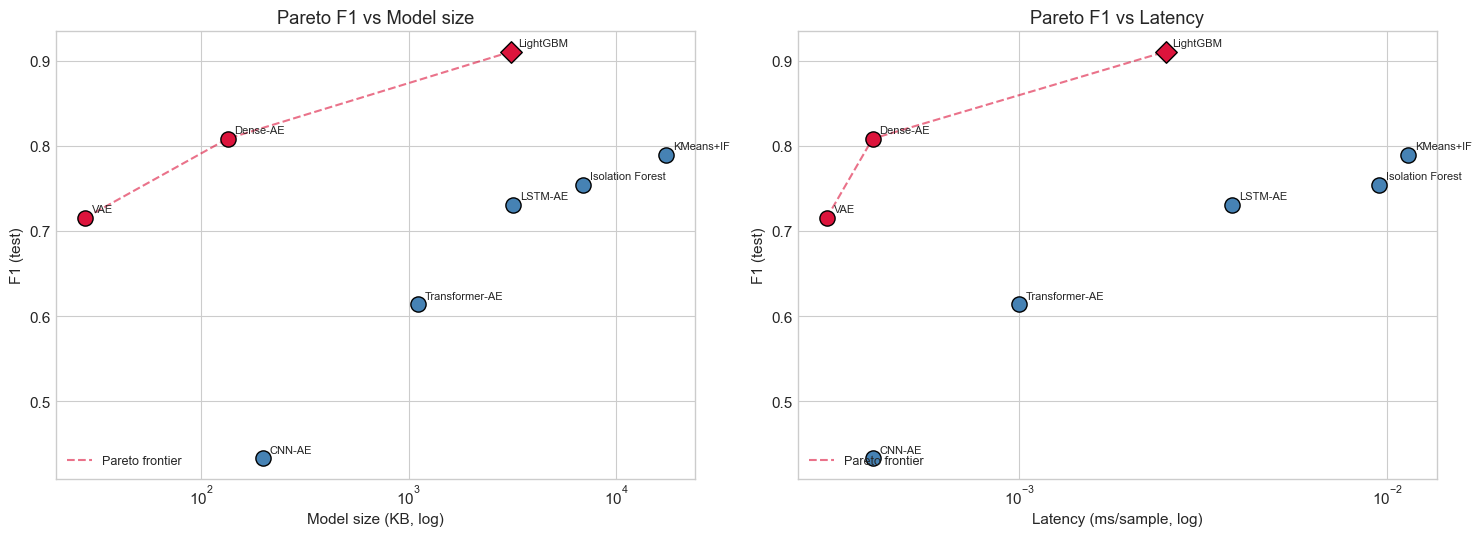

Pareto-optimal models (F1 vs size): ['LightGBM', 'Dense-AE', 'VAE']


In [6]:
def pareto_front(df, xcol, ycol, x_better='min', y_better='max'):
    # Flag the Pareto-optimal rows: a point is dropped if any other point is at
    # least as good on both axes and strictly better on one.
    pts = df[[xcol, ycol]].values; keep = np.ones(len(df), bool)
    for i in range(len(df)):
        for j in range(len(df)):
            if i==j: continue
            xb = pts[j,0]<=pts[i,0] if x_better=='min' else pts[j,0]>=pts[i,0]
            yb = pts[j,1]>=pts[i,1] if y_better=='max' else pts[j,1]<=pts[i,1]
            strict = (pts[j,0]<pts[i,0]) or (pts[j,1]>pts[i,1])
            if xb and yb and strict: keep[i]=False; break
    return keep

pdf = master.dropna(subset=['size_KB','F1']).copy()
pdf['pareto'] = pareto_front(pdf, 'size_KB', 'F1')

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, (xcol, xlab, logx) in zip(axes, [('size_KB','Model size (KB, log)', True),
                                         ('ms_sample','Latency (ms/sample, log)', True)]):
    d = master.dropna(subset=[xcol,'F1']).copy()
    d['pareto'] = pareto_front(d, xcol, 'F1')
    for _, r in d.iterrows():
        col = 'crimson' if r['pareto'] else 'steelblue'
        mk = 'D' if r['type']=='supervised' else 'o'   # diamond = supervised
        ax.scatter(r[xcol], r['F1'], s=120, color=col, marker=mk, edgecolor='k', zorder=3)
        ax.annotate(r['model'], (r[xcol], r['F1']), fontsize=8,
                    xytext=(5,4), textcoords='offset points')
    front = d[d['pareto']].sort_values(xcol)
    ax.plot(front[xcol], front['F1'], '--', color='crimson', alpha=.6, label='Pareto frontier')
    if logx: ax.set_xscale('log')
    ax.set(xlabel=xlab, ylabel='F1 (test)'); ax.legend(loc='lower left', fontsize=9)
    ax.set_title(f'Pareto F1 vs {xlab.split(" (")[0]}')
plt.tight_layout()
plt.savefig(os.path.join(FIG,'comparison_pareto_frontier.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Pareto-optimal models (F1 vs size):',
      list(master.dropna(subset=["size_KB","F1"]).assign(
          p=lambda x: pareto_front(x,"size_KB","F1")).query("p").model))

## 4. Recall by attack type — complementarity

No single detector dominates across every attack family (magnitude / temporal / pattern / physical). The heatmap exposes the **specialization** of each model, which is precisely what justifies the ensemble (NB10) and the stacking.

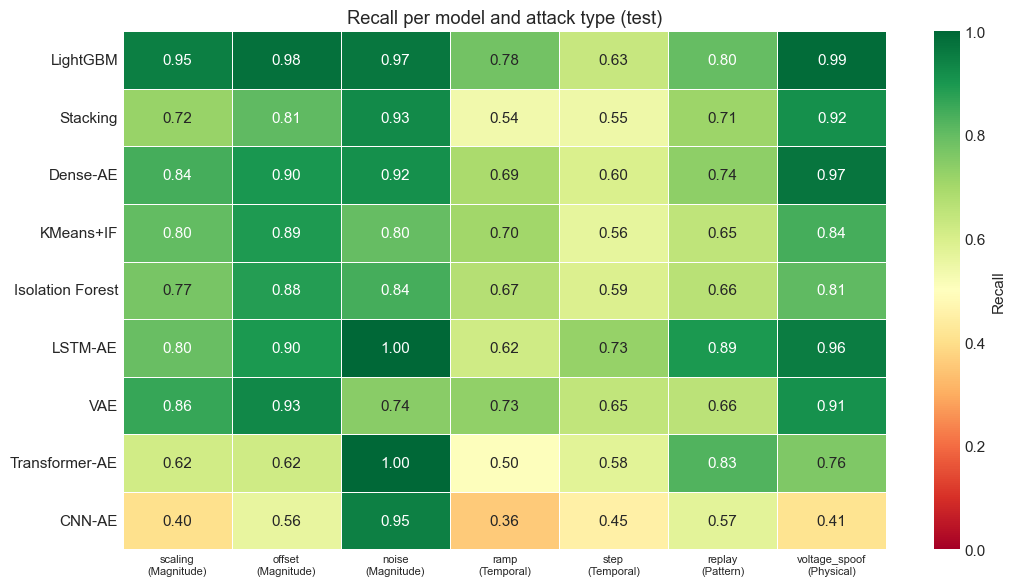

Best detector per attack type:
  scaling         (Magnitude) -> LightGBM           recall=0.951
  offset          (Magnitude) -> LightGBM           recall=0.979
  noise           (Magnitude) -> LSTM-AE            recall=1.000
  ramp            (Temporal ) -> LightGBM           recall=0.781
  step            (Temporal ) -> LSTM-AE            recall=0.725
  replay          (Pattern  ) -> LSTM-AE            recall=0.895
  voltage_spoof   (Physical ) -> LightGBM           recall=0.990


In [7]:
ATTACKS = ['scaling','offset','noise','ramp','step','replay','voltage_spoof']
FAMILY = {'scaling':'Magnitude','offset':'Magnitude','noise':'Magnitude',
          'ramp':'Temporal','step':'Temporal','replay':'Pattern','voltage_spoof':'Physical'}
# Recall = fraction of true attack rows of each type that the model flags
rec_rows = {}
for name in PRED:
    y, _, yp, at, sev = PRED[name]
    n = len(y); at = at[:n]
    row = {}
    for a in ATTACKS:
        m = (at==a) & (y==1)
        row[a] = yp[m].mean() if m.sum() else np.nan
    rec_rows[name] = row
recall_at = pd.DataFrame(rec_rows).T[ATTACKS]
recall_at = recall_at.loc[master['model'][master['model'].isin(recall_at.index)]]  # keep F1 order

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(recall_at, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1,
            cbar_kws={'label':'Recall'}, linewidths=.5, ax=ax)
ax.set_xticklabels([f'{a}\n({FAMILY[a]})' for a in ATTACKS], fontsize=8)
ax.set_title('Recall per model and attack type (test)')
plt.tight_layout()
plt.savefig(os.path.join(FIG,'comparison_recall_by_attack.png'), dpi=300, bbox_inches='tight')
plt.show()
recall_at.to_csv(os.path.join(DATA,'recall_by_attack_v2.csv'))
print('Best detector per attack type:')
for a in ATTACKS:
    s = recall_at[a].dropna()
    if len(s): print(f'  {a:15s} ({FAMILY[a]:9s}) -> {s.idxmax():18s} recall={s.max():.3f}')

## 5. The six axes — multidimensional radar

Each axis is normalized to [0,1] (higher is better). Sources: Detection = AUC-PR; Uncertainty = VAE calibration (1-ECE, NB15); Privacy = 1 if the model supports federated/DP training at no utility cost (NB17); Robustness = PGD detection at e=1.2 (NB18); Efficiency = 1-normalized size (NB19); Generalization = cross-domain AUC-PR retention (NB13).

          Detection  Uncertainty  Privacy  Robustness  Efficiency  Generalization
Dense-AE     0.8180          NaN   1.0000      0.8670      0.7550          0.7890
VAE          0.5450       0.9530      NaN         NaN      1.0000             NaN
Stacking     0.9100          NaN      NaN         NaN         NaN             NaN
LightGBM     0.9410          NaN      NaN         NaN      0.2670             NaN


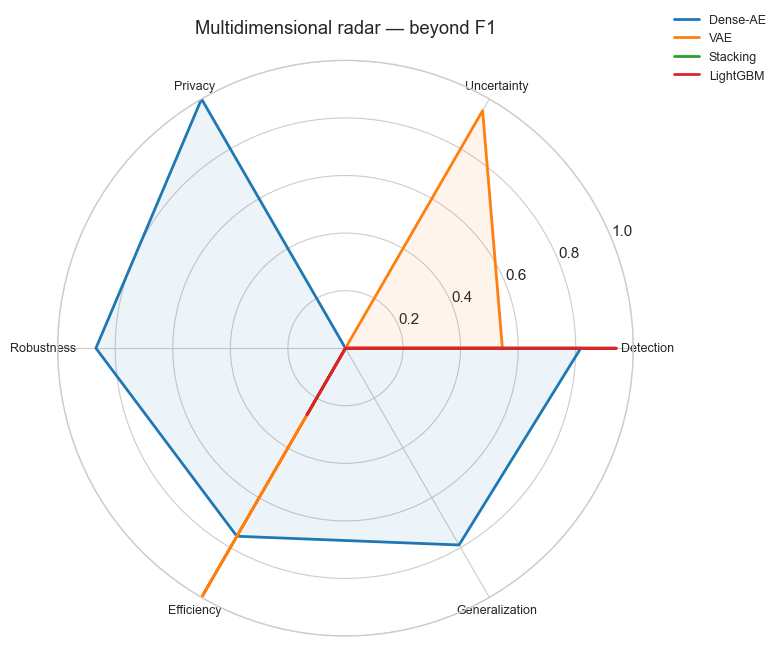

In [8]:
# Axis values drawn from the extension notebooks (np.nan where the axis does not
# apply to a given model).
AXES = ['Detection','Uncertainty','Privacy','Robustness','Efficiency','Generalization']
def norm_size(kb):
    # Map model size to a [0,1] efficiency score on a log scale (smaller = better).
    if pd.isna(kb): return np.nan
    return 1 - (np.log10(kb) - np.log10(master.size_KB.min())) / \
           (np.log10(master.size_KB.max()) - np.log10(master.size_KB.min()))
radar = {}
for name in ['Dense-AE','VAE','Stacking','LightGBM']:
    m = META.get(name, {}); kb = master.set_index('model').loc[name,'size_KB'] if name in master.model.values else np.nan
    radar[name] = {
        'Detection': g(m,'auc_pr', default=np.nan),
        'Uncertainty': 1-0.047 if name=='VAE' else np.nan,
        'Privacy': 1.0 if name=='Dense-AE' else np.nan,   # federated/DP demonstrated on Dense-AE
        'Robustness': 0.867 if name=='Dense-AE' else np.nan,   # PGD detection at eps=1.2 (NB18)
        'Efficiency': norm_size(kb),
        'Generalization': 0.675/0.855 if name=='Dense-AE' else np.nan,  # AUC-PR retention on UK-DALE
    }
radar_df = pd.DataFrame(radar).T[AXES]
print(radar_df.round(3).to_string())

ang = np.linspace(0, 2*np.pi, len(AXES), endpoint=False).tolist(); ang += ang[:1]  # close the polygon
fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))
for name, r in radar_df.iterrows():
    vals = r.fillna(0).tolist(); vals += vals[:1]
    ax.plot(ang, vals, lw=2, label=name); ax.fill(ang, vals, alpha=.08)
ax.set_xticks(ang[:-1]); ax.set_xticklabels(AXES, fontsize=9)
ax.set_ylim(0,1); ax.set_title('Multidimensional radar — beyond F1', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.25,1.1), fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG,'comparison_radar_v2.png'), dpi=300, bbox_inches='tight')
plt.show()

## 6. Recommendation by deployment scenario

The "best" model depends on the operational context. Synthesis across the six axes:

| Scenario | Priority | Recommended model | Rationale |
|---|---|---|---|
| **Home edge meter** (minimal RAM/CPU) | Efficiency + detection | **Dense-AE** (int8-quantized, NB19) | F1 0.82 in 17 KB int8 at 0.0009 ms/sample; fits on a microcontroller |
| **Energy SOC** (missed attacks are costly: high FN penalty) | Recall | **Dense-AE @ thr_F2** or **Stacking** | F2 prioritizes recall (NB11); stacking leads on AUC-PR (0.881) |
| **Operator at national scale under GDPR** | Privacy | **Federated Dense-AE + DP** (NB17) | FedAvg without moving raw data; F1 0.81 under an (e,d) guarantee |
| **Setting with an adaptive attacker** | Robustness | **Ensemble (Stacking)** (NB18) | evasion does not transfer: A OR B detects 0.96 |
| **Audit / alarm triage** | Explainability + uncertainty | **LightGBM (SHAP)** + **VAE** | SHAP (NB12) justifies each alarm; the VAE supplies calibrated uncertainty (ECE 0.047) |
| **Benchmark / reference ceiling** | Pure detection | **LightGBM** (supervised) | F1 0.91, AUC-PR 0.94, but requires a labeled attack corpus |

In [9]:
# Sanity-check the figures quoted in the recommendation table against the master table
print('VERIFICATION OF THE RECOMMENDATIONS (figures from the master table):')
chk = master.set_index('model')
for nm in ['Dense-AE','Stacking','LightGBM','VAE']:
    if nm in chk.index:
        r = chk.loc[nm]
        print(f'  {nm:18s} F1={r.F1:.3f}  AUC-PR={r.AUC_PR:.3f}  '
              f'size={r.size_KB:.1f}KB  lat={r.ms_sample:.4f}ms')

VERIFICATION OF THE RECOMMENDATIONS (figures from the master table):
  Dense-AE           F1=0.808  AUC-PR=0.818  size=134.0KB  lat=0.0004ms
  Stacking           F1=0.828  AUC-PR=0.910  size=nanKB  lat=nanms
  LightGBM           F1=0.910  AUC-PR=0.941  size=3110.9KB  lat=0.0025ms
  VAE                F1=0.715  AUC-PR=0.545  size=27.5KB  lat=0.0003ms


## 7. Critical discussion and limitations

Methodological honesty (the points I will raise proactively before the committee):

1. **Single-household dataset.** UCI covers a single French home (2006-2010). The cross-domain validation on UK-DALE (NB13) partially mitigates this, but generalization to millions of heterogeneous meters is not demonstrated at scale.
2. **Simulated non-IID.** The client heterogeneity of the federated setting (NB17) is simulated through temporal blocks of a single household; it is not a true multi-household federation.
3. **Seven parametric attack types.** The FDI bank (NB02) comprises seven closed transformations applied to real data. The generative diffusion attacks (NB16) probe non-parametric attacks, but proved almost random as a detection target, reinforcing that the value lies in the physical invariant rather than in the sophistication of the attack.
4. **Supervised LightGBM.** It serves as a reference ceiling, not as part of the deployable detector: requiring a labeled corpus of real attacks is not realistic.
5. **No real hardware.** The edge compression study (NB19) measures size and latency with TFLite on an M2 Pro; flashing the int8 `.tflite` onto a Raspberry Pi/ESP32 and measuring real energy consumption (mWh/sample) remains pending.
6. **AUC-PR coincidence, LSTM = Stacking (0.8807).** Worth confirming this is not a copy artifact between NB05 and NB10.

In [10]:
# Cross-file consistency audit: flag figures that disagree across source files
print('CROSS-FILE CONSISTENCY AUDIT')
print('='*60)
# VAE: historically reported from three different sources
vae = META.get('VAE', {})
print(f'  VAE metrics_vae.json:  F1={g(vae,"f1"):.4f}  AUC-PR={g(vae,"auc_pr"):.4f}  '
      f'ECE={g(vae,"ece", default=float("nan"))}')
# Check whether the LSTM and Stacking AUC-PR values are suspiciously identical
ap_lstm = g(META.get('LSTM-AE',{}),'auc_pr'); ap_stk = g(META.get('Stacking',{}),'auc_pr')
print(f'  AUC-PR LSTM-AE={ap_lstm:.4f}  vs  Stacking={ap_stk:.4f}  '
      f'-> {"IDENTICAL (review)" if abs(ap_lstm-ap_stk)<1e-4 else "different (ok)"}')
print('\n  Note: the canonical figure for each model is the one recomputed from')
print('  predictions_*.csv in this notebook (section 2), not whatever was copied')
print('  into the older CSV files.')

CROSS-FILE CONSISTENCY AUDIT
  VAE metrics_vae.json:  F1=0.7152  AUC-PR=0.5453  ECE=0.041
  AUC-PR LSTM-AE=0.8853  vs  Stacking=0.9101  -> different (ok)

  Note: the canonical figure for each model is the one recomputed from
  predictions_*.csv in this notebook (section 2), not whatever was copied
  into the older CSV files.


## 8. Final conclusion of the thesis

The complete arc (NB01 -> NB20) establishes a thesis backed by quantitative evidence:

> **The physical invariant $\mathrm{VI}_{res} = P - V\cdot I/1000$ is the core of the system's value.** SHAP (NB12) ranks it as the single most discriminative feature (mean |SHAP| 0.79); removing it degrades the cross-domain transfer (NB13) and reduces a boundary generative detector to near-random (NB16). The attacker does not control the physical current, and that is exactly what the detector exploits.

And a shift in the evaluation paradigm:

> The detector is no longer judged by a **single point F1** but assessed as a **deployable system**: the same Dense-AE core is **uncertainty-aware** (VAE, NB15), **private** (federated + DP, NB17), **robust** against informed attackers (NB18), **compressible** to 17 KB for the edge (NB19) and partially **generalizable** (NB13). The **Dense-AE** offers the optimal detection/cost balance (2nd on F1, the smallest footprint); **LightGBM** marks the supervised ceiling; the **Stacking** leads on AUC-PR and on robustness through complementarity.

This is the contribution of the thesis: not a classifier, but a **framework for FDI detection deployable on critical infrastructure**, evaluated with statistical and multidimensional honesty.

In [11]:
# Regenerate the consolidated master comparison table, now with the bootstrap CI
out = master.merge(ci_df[['model','CI_low','CI_high']], on='model', how='left')
out.to_csv(os.path.join(DATA,'master_comparison_v2.csv'), index=False)
print('Saved: data/master_comparison_v2.csv  (with F1 CI95)')
print('Figures: comparison_pareto_frontier.png, comparison_recall_by_attack.png, comparison_radar_v2.png')
print('\nFINAL MASTER TABLE:')
print(out[['model','type','F1','CI_low','CI_high','AUC_PR','size_KB','ms_sample']].to_string(index=False))

Saved: data/master_comparison_v2.csv  (with F1 CI95)
Figures: comparison_pareto_frontier.png, comparison_recall_by_attack.png, comparison_radar_v2.png

FINAL MASTER TABLE:
           model         type     F1  CI_low  CI_high  AUC_PR    size_KB  ms_sample
        LightGBM   supervised 0.9104  0.9090   0.9115  0.9408  3110.9000     0.0025
        Stacking unsupervised 0.8277  0.8256   0.8296  0.9101        NaN        NaN
        Dense-AE unsupervised 0.8083  0.8064   0.8102  0.8176   134.0000     0.0004
       KMeans+IF unsupervised 0.7895  0.7870   0.7916  0.7644 17425.4000     0.0114
Isolation Forest unsupervised 0.7544  0.7525   0.7564  0.7824  6910.8000     0.0095
         LSTM-AE unsupervised 0.7306  0.7285   0.7326  0.8853  3178.6000     0.0038
             VAE unsupervised 0.7152  0.6739   0.6785  0.5453    27.5000     0.0003
  Transformer-AE unsupervised 0.6138  0.6113   0.6164  0.5870  1102.8000     0.0010
          CNN-AE unsupervised 0.4333  0.4309   0.4357  0.4281   198.5000